# Feature 2 — XGBoost 주가 예측기 (앙상블 + Optuna)

30년치 미국 주식 데이터를 앙상블 모델로 학습해 향후 30일 주가를 재귀적으로 예측합니다.

- **입력**: 기술적 지표(수익률·이동평균·RSI·거래량비율) + 외부 변수(VIX·금리) + 섹터 ETF 수익률
- **튜닝**: Optuna로 XGBoost·LightGBM 하이퍼파라미터 자동 탐색 (각 50회)
- **앙상블**: XGBoost + LightGBM + RandomForest 예측 평균
- **예측**: 다음날 수익률 → 30일간 반복 적용 → 가격으로 환산
- **학습 주기**: 매일 장 마감 후 배치 자동 실행

In [108]:
# 환경 설정
import sys
sys.path.insert(0, '..')

import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['axes.unicode_minus'] = False
import requests
import datetime

from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
from catboost import CatBoostRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error

import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

from dotenv import load_dotenv
load_dotenv('../.env')

print('환경 설정 완료')

환경 설정 완료


필요한 라이브러리 임포트

### 데이터 수집

In [109]:
from collector.market_data import fetch_macro

# S&P 500 기준으로 30년치 데이터 수집
df_raw = fetch_macro()
# 인덱스의 첫번째 date ~ -1(마지막) date
print(f'수집 기간: {df_raw.index[0].date()} ~ {df_raw.index[-1].date()}')
print(f'shape: {df_raw.shape}')
df_raw[['sp500_close', 'sp500_return', 'sp500_rsi', 'vix', 'tnx']].tail(3)

[Collector] 거시 지표 수집 중... (1926-03-05 ~ 2026-03-05)
[Collector] 수집 완료: 7974행
수집 기간: 1994-06-01 ~ 2026-03-04
shape: (7974, 17)


,sp500_close,sp500_return,sp500_rsi,vix,tnx
date,,,,,
2026-03-02,6881.620117,0.000398,41.642920,21.440001,4.048
2026-03-03,6816.629883,-0.009444,38.404095,23.570000,4.056
2026-03-04,6874.020020,0.008419,44.349112,20.809999,4.073


In [110]:
SECTOR_TICKERS = ['XLF', 'XLE', 'XLK', 'XLV', 'GLD']
HEADERS = {'User-Agent': 'Mozilla/5.0'}

today     = datetime.date.today()
from_date = today - datetime.timedelta(days=365 * 30)
epoch     = datetime.datetime(1970, 1, 1)
from_ts   = int((datetime.datetime.combine(from_date, datetime.time()) - epoch).total_seconds())
to_ts     = int((datetime.datetime.combine(today, datetime.time()) - epoch).total_seconds())

sector_raw = {}
# 섹터 티커들 순회
for ticker in SECTOR_TICKERS:
    # 티커 url 지정
    url    = f'https://query1.finance.yahoo.com/v8/finance/chart/{ticker}'
    params = {'interval': '1d', 'period1': from_ts, 'period2': to_ts}
    resp   = requests.get(url, params=params, headers=HEADERS, timeout=15)
    # resp에서 chart 의 result[0](타임스탬프, 종가 등)
    result = resp.json()['chart']['result'][0]
    # result 에서 종가 추출
    closes = result['indicators']['adjclose'][0]['adjclose']
    # index = 날짜
    index  = pd.to_datetime(result['timestamp'], unit='s').normalize()
    # 섹터 티커들의 종가 데이터를 저장
    sector_raw[ticker] = pd.Series(closes, index=index, name=ticker)
    print(f'{ticker}: {len(sector_raw[ticker])}행')

XLF: 6840행
XLE: 6840행
XLK: 6840행
XLV: 6840행
GLD: 5355행


1. fetch_macro를 활용해서 주가 및 기술 데이터 수집
2. 섹터 ETF(XLF·XLE·XLK·XLV·GLD) 30년치 수집

### 피처 엔지니어링

| 피처 | 설명 |
|------|------|
| `sp500_return` | 전일 대비 수익률 |
| `sp500_return_5` | 5일 누적 수익률 |
| `sp500_return_20` | 20일 누적 수익률 |
| `sp500_ma20_disp` | 20일 이동평균 괴리율 |
| `sp500_rsi` | 14일 RSI |
| `sp500_vol_ratio` | 거래량/20일 평균 |
| `vix` | 변동성 지수 |
| `tnx` | 10년물 금리 |
| `yield_spread` | 장단기 금리차 |
| `xlf/xle/xlk/xlv/gld_return` | 섹터 ETF 수익률 |
| `xlk_sp500_rs` | 기술주 상대 강도 (XLK - S&P500 5일 수익률) |

In [111]:
df = df_raw.copy()

# 추가 수익률 피처 (5일·20일 누적)
# 5일 누적 수익률
df['sp500_return_5']  = df['sp500_close'].pct_change(5)
# 20일 누적 수익률
df['sp500_return_20'] = df['sp500_close'].pct_change(20)

# 섹터 ETF 1일 수익률
for ticker in SECTOR_TICKERS:
    name = ticker.lower()
    s = sector_raw[ticker].reindex(df.index).ffill()
    df[f'{name}_return'] = s.pct_change(1)

# 기술주 상대 강도 (XLK 5일 수익률 - S&P500 5일 수익률)
df['xlk_sp500_rs'] = (
    sector_raw['XLK'].reindex(df.index).ffill().pct_change(5)
    - df['sp500_close'].pct_change(5)
)

# 예측 타깃: 다음날 수익률 (shift -1: 앞으로 당김(다음날 수익률을 현재로))
df['target'] = df['sp500_return'].shift(-1)

# NaN 제거
df = df.dropna()

# 학습 피처 칼럼 모음 (중요도 하위 4개 제거: sp500_return, sp500_return_5, sp500_rsi, gld_return)
FEATURE_COLS = [
    'sp500_return_20',
    'sp500_ma20_disp', 'sp500_vol_ratio',
    'vix', 'tnx', 'yield_spread', 'dxy_return',
    'xlf_return', 'xle_return', 'xlk_return', 'xlv_return',
    'xlk_sp500_rs',
]

print(f'학습 데이터: {len(df)}행 × {len(FEATURE_COLS)}개 피처')
df[FEATURE_COLS].tail(3)

학습 데이터: 5347행 × 12개 피처


,sp500_return_20,sp500_ma20_disp,sp500_vol_ratio,vix,tnx,yield_spread,dxy_return,xlf_return,xle_return,xlk_return,xlv_return,xlk_sp500_rs
date,,,,,,,,,,,,
2026-02-27,-0.012933,0.997508,1.107410,19.860001,3.962,0.384,-0.001943,-0.020381,0.015804,-0.015956,0.017660,-0.010615
2026-03-02,-0.008273,0.998321,1.015171,21.440001,4.048,0.458,0.005108,-0.002528,0.020029,0.005621,-0.010424,0.000948
2026-03-03,-0.022907,0.990040,1.069805,23.570000,4.056,0.461,0.013818,-0.001754,-0.009116,-0.014619,-0.011291,-0.009438


In [112]:
# 라그 피처 (t-2, t-5일 전 VIX·수익률 → 모멘텀 패턴 학습)
df['vix_lag2'] = df['vix'].shift(2)
df['vix_lag5'] = df['vix'].shift(5)
df['ret_lag2'] = df['sp500_return'].shift(2)
df['ret_lag5'] = df['sp500_return'].shift(5)

# 변동성 피처 (20일·60일 수익률 표준편차 → 고변동 구간 인식)
df['vol_20d'] = df['sp500_return'].rolling(20).std()
df['vol_60d'] = df['sp500_return'].rolling(60).std()

# 계절성 피처 (요일: 0=월~4=금, 월: 1~12 → 월말·연말 효과)
df['day_of_week'] = df.index.dayofweek
df['month']       = df.index.month

# 시장 레짐 (MA200 기준: 1=상승장, 0=하락장)
df['is_bull'] = (df['sp500_close'] > df['sp500_close'].rolling(200).mean()).astype(int)

df = df.dropna()

FEATURE_COLS = FEATURE_COLS + [
    'vix_lag2', 'vix_lag5', 'ret_lag2', 'ret_lag5',
    'vol_20d', 'vol_60d',
    'day_of_week', 'month', 'is_bull',
]

print(f'피처 추가 후: {len(FEATURE_COLS)}개 피처')
df[['vix_lag2', 'vol_20d', 'day_of_week', 'is_bull']].tail(3)

피처 추가 후: 21개 피처


,vix_lag2,vol_20d,day_of_week,is_bull
date,,,,
2026-02-27,17.930000,0.008339,4,1
2026-03-02,18.629999,0.008296,0,1
2026-03-03,19.860001,0.008414,1,1


In [113]:
# 타깃 이상치 클리핑 (±3σ 초과 극단값 제거 → 학습 왜곡 방지)
ret_mean = df['target'].mean()
ret_std  = df['target'].std()
df['target'] = df['target'].clip(lower=ret_mean - 3*ret_std, upper=ret_mean + 3*ret_std)
print(f'클리핑 범위: [{ret_mean - 3*ret_std:.4f}, {ret_mean + 3*ret_std:.4f}]')
print(f'타깃 통계  | 평균: {df["target"].mean():.6f}, 표준편차: {df["target"].std():.6f}')

클리핑 범위: [-0.0358, 0.0366]
타깃 통계  | 평균: 0.000420, 표준편차: 0.010606


3. 5일/20일 누적 수익률 피처 생성
4. 섹터 ETF 수익률 및 기술주 상대 강도 피처 생성
5. 예측 답안 피처를 생성: 그 다음날 주가
6. 결측치는 제거
7. 학습 피처 정의

### 학습 / 검증 분할 및 앙상블 학습

- 마지막 252일(약 1년)을 검증셋으로 사용
- 나머지를 학습셋으로 사용
- Optuna로 XGBoost·LightGBM 파라미터 자동 탐색 (각 50회)
- XGBoost + LightGBM + RandomForest 앙상블

In [114]:
VALID_DAYS = 252  # 검증 기간 (약 1년) -> 학습 중 성능 개선을 위한 검증 기간

X = df[FEATURE_COLS].values
y = df['target'].values

# 시계열 순서를 유지한 train/valid 분할
X_train, X_valid = X[:-VALID_DAYS], X[-VALID_DAYS:]  # 훈련은 앞의 데이터 검증은 뒤의 데이터
y_train, y_valid = y[:-VALID_DAYS], y[-VALID_DAYS:]

# 피처 정규화
scaler    = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_valid_s = scaler.transform(X_valid)

# 최근 데이터에 더 높은 가중치 (지수 감쇠: 오래된 데이터일수록 가중치 감소)
decay = 0.9995
sample_weight = decay ** np.arange(len(X_train) - 1, -1, -1)

print(f'Train: {len(X_train)}행, Valid: {len(X_valid)}행')
print(f'샘플 가중치 범위: {sample_weight.min():.4f} ~ {sample_weight.max():.4f}')

Train: 5036행, Valid: 252행
샘플 가중치 범위: 0.0806 ~ 1.0000


In [115]:
def objective_xgb(trial):
    params = {
        'n_estimators':     trial.suggest_int('n_estimators', 300, 1500),
        'learning_rate':    trial.suggest_float('learning_rate', 0.005, 0.1, log=True),
        'max_depth':        trial.suggest_int('max_depth', 3, 7),
        'subsample':        trial.suggest_float('subsample', 0.5, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.5, 1.0),
        'min_child_weight': trial.suggest_int('min_child_weight', 1, 5),
        'gamma':            trial.suggest_float('gamma', 0.0, 0.3),
        'random_state': 42,
        'verbosity': 0,
    }
    m = XGBRegressor(**params)
    m.fit(X_train_s, y_train, sample_weight=sample_weight)
    return mean_absolute_error(y_valid, m.predict(X_valid_s))

def objective_lgb(trial):
    params = {
        'n_estimators':      trial.suggest_int('n_estimators', 300, 1500),
        'learning_rate':     trial.suggest_float('learning_rate', 0.005, 0.1, log=True),
        'max_depth':         trial.suggest_int('max_depth', 3, 7),
        'subsample':         trial.suggest_float('subsample', 0.5, 1.0),
        'colsample_bytree':  trial.suggest_float('colsample_bytree', 0.5, 1.0),
        'min_child_samples': trial.suggest_int('min_child_samples', 5, 50),
        'num_leaves':        trial.suggest_int('num_leaves', 20, 100),
        'random_state': 42,
        'verbose': -1,
    }
    m = LGBMRegressor(**params)
    m.fit(X_train_s, y_train, sample_weight=sample_weight)
    return mean_absolute_error(y_valid, m.predict(X_valid_s))

def objective_cat(trial):
    params = {
        'iterations':    trial.suggest_int('iterations', 300, 1500),
        'learning_rate': trial.suggest_float('learning_rate', 0.005, 0.1, log=True),
        'depth':         trial.suggest_int('depth', 3, 8),
        'l2_leaf_reg':   trial.suggest_float('l2_leaf_reg', 1.0, 10.0),
    }
    m = CatBoostRegressor(**params, random_seed=42, verbose=0)
    m.fit(X_train_s, y_train, sample_weight=sample_weight)
    return mean_absolute_error(y_valid, m.predict(X_valid_s))

print('XGBoost 튜닝 중...')
study_xgb = optuna.create_study(direction='minimize')
study_xgb.optimize(objective_xgb, n_trials=100)

print('LightGBM 튜닝 중...')
study_lgb = optuna.create_study(direction='minimize')
study_lgb.optimize(objective_lgb, n_trials=100)

print('CatBoost 튜닝 중...')
study_cat = optuna.create_study(direction='minimize')
study_cat.optimize(objective_cat, n_trials=100)

print('\nXGBoost  최적 파라미터:', study_xgb.best_params)
print(f'XGBoost  Best MAE: {study_xgb.best_value:.6f}')
print()
print('LightGBM 최적 파라미터:', study_lgb.best_params)
print(f'LightGBM Best MAE: {study_lgb.best_value:.6f}')
print()
print('CatBoost 최적 파라미터:', study_cat.best_params)
print(f'CatBoost Best MAE: {study_cat.best_value:.6f}')

XGBoost 튜닝 중...
LightGBM 튜닝 중...
CatBoost 튜닝 중...

XGBoost  최적 파라미터: {'n_estimators': 351, 'learning_rate': 0.05807567351131772, 'max_depth': 6, 'subsample': 0.5306183357674767, 'colsample_bytree': 0.672124074919872, 'min_child_weight': 2, 'gamma': 0.2823250871895101}
XGBoost  Best MAE: 0.006666

LightGBM 최적 파라미터: {'n_estimators': 300, 'learning_rate': 0.005838872154330783, 'max_depth': 6, 'subsample': 0.6500310350433729, 'colsample_bytree': 0.7202892360424024, 'min_child_samples': 46, 'num_leaves': 57}
LightGBM Best MAE: 0.006689

CatBoost 최적 파라미터: {'iterations': 613, 'learning_rate': 0.018862629797362227, 'depth': 8, 'l2_leaf_reg': 8.921645724559855}
CatBoost Best MAE: 0.006626


In [116]:
# XGBoost 학습
model_xgb = XGBRegressor(**study_xgb.best_params, random_state=42, verbosity=0)
model_xgb.fit(X_train_s, y_train, sample_weight=sample_weight)

# LightGBM 학습
model_lgb = LGBMRegressor(**study_lgb.best_params, random_state=42, verbose=-1)
model_lgb.fit(X_train_s, y_train, sample_weight=sample_weight)

# CatBoost 학습
model_cat = CatBoostRegressor(**study_cat.best_params, random_seed=42, verbose=0)
model_cat.fit(X_train_s, y_train, sample_weight=sample_weight)

print('모델 학습 완료')

모델 학습 완료


In [117]:
# 검증셋 예측
pred_xgb = model_xgb.predict(X_valid_s)
pred_lgb = model_lgb.predict(X_valid_s)
pred_cat = model_cat.predict(X_valid_s)

# 개별 모델 MAE
mae_xgb = mean_absolute_error(y_valid, pred_xgb)
mae_lgb = mean_absolute_error(y_valid, pred_lgb)
mae_cat = mean_absolute_error(y_valid, pred_cat)

# MAE 역수 가중 앙상블
w_xgb = 1 / mae_xgb
w_lgb = 1 / mae_lgb
w_cat = 1 / mae_cat
total = w_xgb + w_lgb + w_cat

pred_ens = (w_xgb*pred_xgb + w_lgb*pred_lgb + w_cat*pred_cat) / total
mae_ens  = mean_absolute_error(y_valid, pred_ens)

print(f'XGBoost  MAE: {mae_xgb:.6f} ({mae_xgb*100:.4f}%)')
print(f'LightGBM MAE: {mae_lgb:.6f} ({mae_lgb*100:.4f}%)')
print(f'CatBoost MAE: {mae_cat:.6f} ({mae_cat*100:.4f}%)')
print(f'앙상블   MAE: {mae_ens:.6f} ({mae_ens*100:.4f}%)')
print(f'\n가중치 | XGB:{w_xgb/total:.3f} LGB:{w_lgb/total:.3f} CAT:{w_cat/total:.3f}')

XGBoost  MAE: 0.006666 (0.6666%)
LightGBM MAE: 0.006689 (0.6689%)
CatBoost MAE: 0.006626 (0.6626%)
앙상블   MAE: 0.006649 (0.6649%)

가중치 | XGB:0.333 LGB:0.332 CAT:0.335


In [118]:
from sklearn.linear_model import Ridge

# 스태킹: 검증셋 전반부로 메타 러너 학습, 후반부로 평가
split = len(y_valid) // 2

# 3모델 예측값을 메타 러너 입력으로 구성
meta_X = np.column_stack([pred_xgb, pred_lgb, pred_cat])

# Ridge 메타 러너 학습 (검증셋 전반부)
meta_model = Ridge(alpha=1.0, positive=True)  # positive: 음수 가중치 방지
meta_model.fit(meta_X[:split], y_valid[:split])

# 검증셋 후반부로 평가
pred_stack = meta_model.predict(meta_X[split:])
mae_stack  = mean_absolute_error(y_valid[split:], pred_stack)
acc_stack  = (np.sign(y_valid[split:]) == np.sign(pred_stack)).mean()

print(f'스태킹 MAE:         {mae_stack:.6f} ({mae_stack*100:.4f}%)')
print(f'스태킹 방향 정확도: {acc_stack*100:.1f}%')
print(f'\n메타 러너 가중치:')
for name, coef in zip(['XGB', 'LGB', 'CAT'], meta_model.coef_):
    print(f'  {name}: {coef:.4f}')

스태킹 MAE:         0.005457 (0.5457%)
스태킹 방향 정확도: 58.7%

메타 러너 가중치:
  XGB: 0.0000
  LGB: 0.0004
  CAT: 0.0007


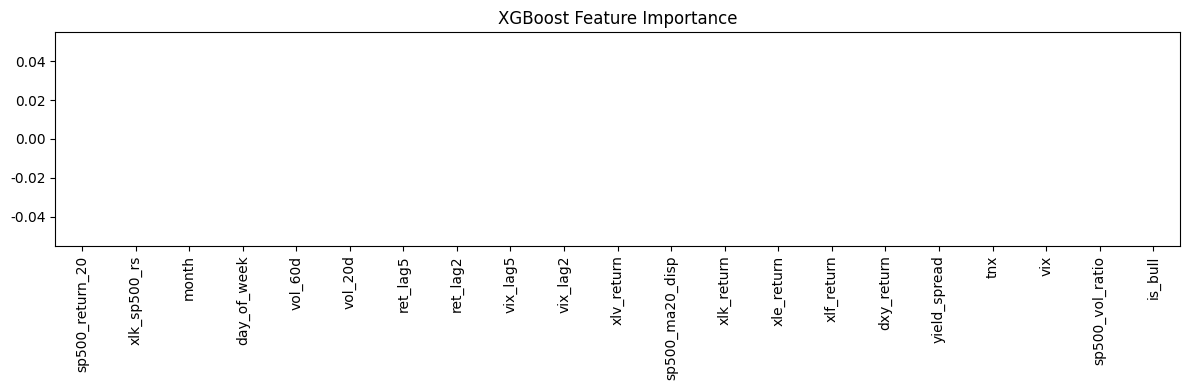

sp500_return_20    0.0
xlk_sp500_rs       0.0
month              0.0
day_of_week        0.0
vol_60d            0.0
vol_20d            0.0
ret_lag5           0.0
ret_lag2           0.0
vix_lag5           0.0
vix_lag2           0.0
xlv_return         0.0
sp500_ma20_disp    0.0
xlk_return         0.0
xle_return         0.0
xlf_return         0.0
dxy_return         0.0
yield_spread       0.0
tnx                0.0
vix                0.0
sp500_vol_ratio    0.0
is_bull            0.0
dtype: float32


In [119]:
importance = pd.Series(
    model_xgb.feature_importances_,
    index=FEATURE_COLS
).sort_values(ascending=False)

importance.plot(kind='bar', figsize=(12, 4), title='XGBoost Feature Importance')
plt.tight_layout()
plt.show()
print(importance)

7. 검증 기간 설정
8. 훈련/검증 분할
9. 변수 정규화
10. Optuna로 XGBoost·LightGBM 파라미터 자동 튜닝
11. 앙상블(XGB + LGB + RF) 학습 및 성능 테스트

In [120]:
# 방향성 예측 성능 테스트
# 검증(정답) 데이터의 방향을 추출
actual_dir = np.sign(y_valid)
# 학습 후 추론 데이터의 방향을 추출
pred_dir   = np.sign(pred_ens)
# 정확성 측정
accuracy   = (actual_dir == pred_dir).mean()
print(f'앙상블 방향 정확도: {accuracy*100:.1f}%')

앙상블 방향 정확도: 58.3%


**단순 XGBoost 모델 예측보다 XGBoost + LightGBM 앙상블 + 섹터 ETF 피처 추가  + Optuna 튜닝 으로 52 % -> 56% 로 방향성 예측 개선**

12. 방향성 예측 성능 테스트

### 향후 30일 재귀 예측

매 스텝마다 예측된 수익률로 다음날 가격을 계산하고,
기술적 지표(MA괴리율·RSI·거래량비율)는 재계산합니다.
외부 변수(VIX·금리·섹터 ETF)는 최근 20일 평균으로 고정합니다.

In [121]:
PREDICT_DAYS = 30

# 외부 변수 고정값 (최근 1년 평균)
vix_mean       = df['vix'].iloc[-252:].mean()
tnx_mean       = df['tnx'].iloc[-252:].mean()
yield_mean     = df['yield_spread'].iloc[-252:].mean()
dxy_mean       = df['dxy_return'].iloc[-252:].mean()
vol_ratio_mean = df['sp500_vol_ratio'].iloc[-252:].mean()

sector_means = {
    'xlf_return':   df['xlf_return'].iloc[-252:].mean(),
    'xle_return':   df['xle_return'].iloc[-252:].mean(),
    'xlk_return':   df['xlk_return'].iloc[-252:].mean(),
    'xlv_return':   df['xlv_return'].iloc[-252:].mean(),
    'xlk_sp500_rs': df['xlk_sp500_rs'].iloc[-252:].mean(),
}

# 예측 날짜 사전 생성 (계절성 피처 계산용)
future_dates = pd.bdate_range(start=df.index[-1] + pd.Timedelta(days=1), periods=PREDICT_DAYS)

print(f'고정 외부변수 | VIX: {vix_mean:.2f}, TNX: {tnx_mean:.2f}, 금리차: {yield_mean:.2f}')
print(f'예측 기간: {future_dates[0].date()} ~ {future_dates[-1].date()}')

고정 외부변수 | VIX: 19.10, TNX: 4.23, 금리차: 0.28
예측 기간: 2026-03-04 ~ 2026-04-14


In [122]:
# 최근 가격 시계열 (기술 지표 재계산용 버퍼)
price_buf = list(df['sp500_close'].values)
last_price = price_buf[-1]

predicted_prices = [last_price]

for step in range(PREDICT_DAYS):
    prices    = pd.Series(price_buf)
    returns_s = prices.pct_change(1)

    # 기술적 지표
    ret20     = prices.pct_change(20).iloc[-1]
    ma20      = prices.rolling(20).mean().iloc[-1]
    ma20_disp = prices.iloc[-1] / ma20 if ma20 > 0 else 1.0

    # 라그 피처 (가격 버퍼에서 직접 계산)
    ret_lag2 = returns_s.iloc[-2] if len(returns_s) >= 3 else 0.0
    ret_lag5 = returns_s.iloc[-5] if len(returns_s) >= 6 else 0.0

    # 변동성 피처
    vol_20d_val = returns_s.iloc[-20:].std()
    vol_60d_val = returns_s.iloc[-60:].std()

    # 계절성 피처 (예측 날짜 기준)
    cur_date = future_dates[step]
    dow_val  = cur_date.dayofweek
    mon_val  = cur_date.month

    # 시장 레짐 (MA200 기준)
    ma200    = prices.rolling(200).mean().iloc[-1]
    bull_val = 1 if prices.iloc[-1] > ma200 else 0

    # 피처 벡터 구성 (FEATURE_COLS 순서 일치: 21개)
    feat = np.array([[
        ret20, ma20_disp, vol_ratio_mean,
        vix_mean, tnx_mean, yield_mean, dxy_mean,
        sector_means['xlf_return'], sector_means['xle_return'],
        sector_means['xlk_return'], sector_means['xlv_return'],
        sector_means['xlk_sp500_rs'],
        vix_mean, vix_mean,          # vix_lag2, vix_lag5 (고정)
        ret_lag2, ret_lag5,
        vol_20d_val, vol_60d_val,
        dow_val, mon_val, bull_val,
    ]])
    feat_s = scaler.transform(feat)

    # 3모델 예측 → 메타 러너 앙상블
    p_xgb = float(model_xgb.predict(feat_s)[0])
    p_lgb = float(model_lgb.predict(feat_s)[0])
    p_cat = float(model_cat.predict(feat_s)[0])
    pred_ret = float(meta_model.predict([[p_xgb, p_lgb, p_cat]])[0])

    next_price = price_buf[-1] * (1 + pred_ret)
    predicted_prices.append(next_price)
    price_buf.append(next_price)  # 버퍼에 추가 → 다음 스텝 입력

print(f'현재가: {last_price:.2f}')
print(f'30일 후 예측가: {predicted_prices[-1]:.2f}')
print(f'예상 수익률: {(predicted_prices[-1]/last_price - 1)*100:.2f}%')

현재가: 6816.63
30일 후 예측가: 6953.90
예상 수익률: 2.01%


### 예측 결과 시각화

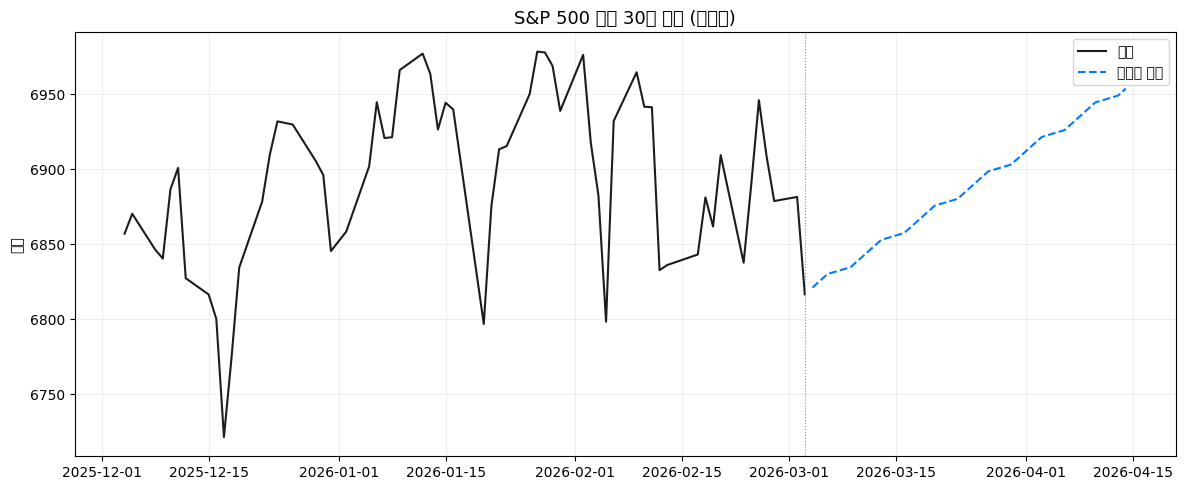

In [123]:
# 최근 60일 실제 + 30일 예측 시각화
recent_prices = df['sp500_close'].iloc[-60:]
recent_dates  = df.index[-60:]

# 예측 날짜 생성 (영업일 기준)
last_date = df.index[-1]
future_dates = pd.bdate_range(start=last_date + pd.Timedelta(days=1), periods=PREDICT_DAYS)

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(recent_dates, recent_prices, color='#1C1C1E', linewidth=1.5, label='실제')
ax.plot(future_dates, predicted_prices[1:], color='#007AFF', linewidth=1.5,
        linestyle='--', label='앙상블 예측')
ax.axvline(last_date, color='#8E8E93', linewidth=0.8, linestyle=':')
ax.set_title(f'S&P 500 향후 {PREDICT_DAYS}일 예측 (앙상블)', fontsize=13)
ax.set_ylabel('지수')
ax.legend()
ax.grid(alpha=0.2)
plt.tight_layout()
plt.show()